In [1]:
#Import Dependencies and Set Architecture Parameters
import numpy as np
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Dense, Dropout, Flatten, concatenate, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

# Architecture Parameters
max_word_length = 75
vocab_size = 274407
embedding_dim = 300
max_char_length = 300
char_vocab_size = 72
char_embedding_dim = 50
struct_feature_dim = 135
filter_sizes = [3, 4, 5]
num_filters = 128
dropout_rate = 0.5

print("Parameters set successfully")
print(f"Word sequences: {max_word_length} tokens, vocab: {vocab_size}")
print(f"Character sequences: {max_char_length} chars, vocab: {char_vocab_size}")
print(f"Structural features: {struct_feature_dim} dimensions")
print(f"CNN filters: {filter_sizes} sizes, {num_filters} filters each")


Parameters set successfully
Word sequences: 75 tokens, vocab: 274407
Character sequences: 300 chars, vocab: 72
Structural features: 135 dimensions
CNN filters: [3, 4, 5] sizes, 128 filters each


In [2]:
# Define Word-Level CNN Branch

def create_word_branch(embedding_matrix):
    word_input = Input(shape=(max_word_length,), name='word_input')
    word_embedding = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_word_length,
        trainable=True,
        name='word_embedding'
    )(word_input)
    word_convs = []
    for filter_size in filter_sizes:
        conv = Conv1D(num_filters, filter_size, activation='relu')(word_embedding)
        pool = MaxPooling1D(pool_size=max_word_length - filter_size + 1)(conv)
        flatten = Flatten()(pool)
        word_convs.append(flatten)
    word_output = concatenate(word_convs)
    return word_input, word_output

print("Word branch function defined successfully")
print("Features: GloVe embeddings + parallel Conv1D layers (filters: 3, 4, 5)")


Word branch function defined successfully
Features: GloVe embeddings + parallel Conv1D layers (filters: 3, 4, 5)


In [3]:
#Define Character-Level CNN Branch
def create_char_branch():
    char_input = Input(shape=(max_char_length,), name='char_input')
    char_embedding = Embedding(
        input_dim=char_vocab_size,
        output_dim=char_embedding_dim,
        input_length=max_char_length,
        trainable=True,
        name='char_embedding'
    )(char_input)
    char_convs = []
    for filter_size in filter_sizes:
        conv = Conv1D(num_filters, filter_size, activation='relu')(char_embedding)
        pool = MaxPooling1D(pool_size=max_char_length - filter_size + 1)(conv)
        flatten = Flatten()(pool)
        char_convs.append(flatten)
    char_output = concatenate(char_convs)
    return char_input, char_output

print("Character branch function defined successfully")
print("Features: Character embeddings (50D) + parallel Conv1D layers (filters: 3, 4, 5)")


Character branch function defined successfully
Features: Character embeddings (50D) + parallel Conv1D layers (filters: 3, 4, 5)


In [4]:
#Define Structural Features Branch
def create_structural_branch():
    struct_input = Input(shape=(struct_feature_dim,), name='struct_input')
    struct_dense1 = Dense(256, activation='relu',kernel_regularizer=None)(struct_input)
    struct_dropout1 = Dropout(dropout_rate)(struct_dense1)
    struct_dense2 = Dense(128, activation='relu',kernel_regularizer=None)(struct_dropout1)
    return struct_input, struct_dense2

print("Structural branch function defined successfully")
print("Features: 135 SQL analysis features → Dense(256) → Dropout → Dense(128)")


Structural branch function defined successfully
Features: 135 SQL analysis features → Dense(256) → Dropout → Dense(128)


In [5]:
# Build Complete Multi-Input CNN Model
def build_multi_input_cnn(embedding_matrix):
    word_input, word_output = create_word_branch(embedding_matrix)
    char_input, char_output = create_char_branch()
    struct_input, struct_output = create_structural_branch()
    combined = concatenate([word_output, char_output, struct_output])
    combined = BatchNormalization()(combined)
    combined = Dropout(dropout_rate)(combined)
    combined = Dense(256, activation='relu',kernel_regularizer=regularizers.l2(1e-5))(combined)
    combined = Dropout(dropout_rate)(combined)
    combined = Dense(64, activation='relu',kernel_regularizer=regularizers.l2(1e-5))(combined)
    output = Dense(1, activation='sigmoid')(combined)
    model = Model(inputs=[word_input, char_input, struct_input], outputs=output)
    return model

print("Multi-input CNN model builder defined successfully")
print("Architecture: Word CNN + Character CNN + Structural Dense → Fusion → Classification")
print("Components: 3 parallel branches → Concatenate → BatchNorm → Dropout → Dense(256) → Dense(64) → Sigmoid")


Multi-input CNN model builder defined successfully
Architecture: Word CNN + Character CNN + Structural Dense → Fusion → Classification
Components: 3 parallel branches → Concatenate → BatchNorm → Dropout → Dense(256) → Dense(64) → Sigmoid


In [6]:
import numpy as np

# Load your actual embedding matrix
embedding_matrix = np.load('embedding_matrix.npy')
print(f"Loaded embedding matrix shape: {embedding_matrix.shape}")

# Update parameters to match actual embedding matrix dimensions
vocab_size_actual = embedding_matrix.shape[0]  # 20000
embedding_dim_actual = embedding_matrix.shape[1]  # 300

print(f"Updated parameters:")
print(f"Actual vocab size: {vocab_size_actual}")
print(f"Actual embedding dim: {embedding_dim_actual}")

# Redefine create_word_branch to use actual dimensions
def create_word_branch_corrected(embedding_matrix):
    word_input = Input(shape=(max_word_length,), name='word_input')
    word_embedding = Embedding(
        input_dim=embedding_matrix.shape[0],  # Use actual vocab size
        output_dim=embedding_matrix.shape[1], # Use actual embedding dim
        weights=[embedding_matrix],
        input_length=max_word_length,
        trainable=True,
        name='word_embedding'
    )(word_input)
    word_convs = []
    for filter_size in filter_sizes:
        conv = Conv1D(num_filters, filter_size, activation='relu')(word_embedding)
        pool = MaxPooling1D(pool_size=max_word_length - filter_size + 1)(conv)
        flatten = Flatten()(pool)
        word_convs.append(flatten)
    word_output = concatenate(word_convs)
    return word_input, word_output

# Build corrected model
def build_multi_input_cnn_corrected(embedding_matrix):
    word_input, word_output = create_word_branch_corrected(embedding_matrix)
    char_input, char_output = create_char_branch()
    struct_input, struct_output = create_structural_branch()
    combined = concatenate([word_output, char_output, struct_output])
    combined = BatchNormalization()(combined)
    combined = Dropout(dropout_rate)(combined)
    combined = Dense(256, activation='relu',kernel_regularizer=regularizers.l2(1e-5))(combined)
    combined = Dropout(dropout_rate)(combined)
    combined = Dense(64, activation='relu',kernel_regularizer=regularizers.l2(1e-5))(combined)
    output = Dense(1, activation='sigmoid')(combined)
    model = Model(inputs=[word_input, char_input, struct_input], outputs=output)
    return model

# Create model with corrected dimensions
model = build_multi_input_cnn_corrected(embedding_matrix)
model.summary()

print("Model created successfully!")
print(f"Total parameters: {model.count_params():,}")
print(f"Word input shape: {model.inputs[0].shape}")
print(f"Character input shape: {model.inputs[1].shape}")
print(f"Structural input shape: {model.inputs[2].shape}")
print(f"Output shape: {model.output.shape}")


Loaded embedding matrix shape: (20000, 300)
Updated parameters:
Actual vocab size: 20000
Actual embedding dim: 300
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 word_input (InputLayer)        [(None, 75)]         0           []                               
                                                                                                  
 char_input (InputLayer)        [(None, 300)]        0           []                               
                                                                                                  
 word_embedding (Embedding)     (None, 75, 300)      6000000     ['word_input[0][0]']             
                                                                                                  
 char_embedding (Embedding)     (None, 300, 50)      3600        ['char_input[

In [7]:
# #Optimizer Comparison with Adequate Training
# from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adagrad
# from tensorflow.keras.callbacks import EarlyStopping
# import pandas as pd

# # Define optimizer candidates for systematic comparison
# optimizers_config = {
#     'Adam': Adam(learning_rate=0.001),
#     'Adam_lower_lr': Adam(learning_rate=0.0005),
#     'RMSprop': RMSprop(learning_rate=0.001),
#     'SGD_momentum': SGD(learning_rate=0.01, momentum=0.9),
#     'Adagrad': Adagrad(learning_rate=0.01)
# }

# print("Systematic Optimizer Comparison Setup - Updated")
# print("="*50)

# # Training configuration for optimizer comparison
# comparison_epochs = 15  # Sufficient for CNN convergence assessment
# early_stopping = EarlyStopping(
#     monitor='val_accuracy',
#     patience=5,
#     restore_best_weights=True,
#     verbose=1
# )

# print("Training Configuration:")
# print(f"- Epochs per optimizer: {comparison_epochs}")
# print("- Monitor: validation accuracy")
# print("- Batch size: 32")
# print("- Restore best weights: enabled")

# print(f"\nOptimizers to compare: {list(optimizers_config.keys())}")

# # Function for comprehensive optimizer comparison
# def compare_optimizers_comprehensive(model_builder, embedding_matrix, train_data, val_data):
#     """
#     Compare all optimizers with adequate training time
#     """
#     results = []
    
#     for opt_name, optimizer in optimizers_config.items():
#         print(f"\nTraining with {opt_name}...")
        
#         # Fresh model for each optimizer
#         test_model = model_builder(embedding_matrix)
#         test_model.compile(
#             optimizer=optimizer,
#             loss='binary_crossentropy',
#             metrics=['accuracy', 'precision', 'recall']
#         )
        
#         # Train with early stopping
#         history = test_model.fit(
#             train_data[0], train_data[1],
#             validation_data=(val_data[0], val_data[1]),
#             epochs=comparison_epochs,
#             batch_size=32,
#             callbacks=[early_stopping],
#             verbose=1
#         )
        
#         # Get best validation metrics
#         best_epoch = len(history.history['val_accuracy'])
#         val_acc = max(history.history['val_accuracy'])
#         val_precision = max(history.history['val_precision'])
#         val_recall = max(history.history['val_recall'])
#         f1_score = 2 * (val_precision * val_recall) / (val_precision + val_recall)
        
#         results.append({
#             'optimizer': opt_name,
#             'best_epoch': best_epoch,
#             'val_accuracy': val_acc,
#             'val_precision': val_precision,
#             'val_recall': val_recall,
#             'f1_score': f1_score
#         })
        
#         print(f"{opt_name} - Best Val Accuracy: {val_acc:.4f} at epoch {best_epoch}")
    
#     # Comprehensive results analysis
#     results_df = pd.DataFrame(results)
#     results_df = results_df.sort_values('val_accuracy', ascending=False)
    
#     print("\nOptimizer Comparison Results:")
#     print("="*60)
#     print(results_df.to_string(index=False))
    
#     best_optimizer = results_df.iloc[0]['optimizer']
#     best_accuracy = results_df.iloc[0]['val_accuracy']
    
#     print(f"\nBest optimizer: {best_optimizer}")
#     print(f"Best validation accuracy: {best_accuracy:.4f}")
#     print("Ready for full training with selected optimizer")
    
#     return best_optimizer, results_df

# print("\nPhase 4 COMPLETED with comprehensive optimizer comparison")
# print("✅ CNN Architecture Selection (Multi-input 1D CNN)")
# print("✅ Model Components Design (6.8M parameters)")
# print("✅ Model Compilation Setup (15-epoch systematic comparison)")
# print("\nNext: Phase 5 empirical optimizer testing on your malicious query data")


In [8]:
import pandas as pd
import numpy as np

# Convert CSV files to .npy format
print("Converting CSV files to .npy format...")

# List of files to convert (adjust paths based on your file locations)
csv_files = {
    'train_sql_features.csv': 'train_sql_features.npy',
    'val_sql_features.csv': 'val_sql_features.npy',
    'test_sql_features.csv': 'test_sql_features.npy'
}

# Try multiple possible paths for your CSV files
possible_paths = ['', 'data/processed/', '../data/processed/', 'notebooks/']

for csv_name, npy_name in csv_files.items():
    converted = False
    
    for path_prefix in possible_paths:
        csv_path = path_prefix + csv_name
        try:
            # Load CSV file
            df = pd.read_csv(csv_path)
            print(f"✅ Loaded {csv_path} with shape: {df.shape}")
            
            # Convert to numpy array
            np_array = df.values
            
            # Save as .npy file
            np.save(npy_name, np_array)
            print(f"✅ Saved as {npy_name} with shape: {np_array.shape}")
            
            converted = True
            break
            
        except FileNotFoundError:
            continue
    
    if not converted:
        print(f"❌ Could not find {csv_name} in any of the paths: {possible_paths}")

print("CSV to NPY conversion completed!")


Converting CSV files to .npy format...
✅ Loaded ../data/processed/train_sql_features.csv with shape: (55658, 135)
✅ Saved as train_sql_features.npy with shape: (55658, 135)
✅ Loaded ../data/processed/val_sql_features.csv with shape: (11979, 135)
✅ Saved as val_sql_features.npy with shape: (11979, 135)
✅ Loaded ../data/processed/test_sql_features.csv with shape: (11934, 135)
✅ Saved as test_sql_features.npy with shape: (11934, 135)
CSV to NPY conversion completed!


Loading preprocessed datasets...
 Loaded X_train_preprocessed.npy with shape: (55658, 75)
 Loaded train_char_sequences.npy with shape: (55658, 300)
 Loaded train_sql_features.npy with shape: (55658, 135)
 Loaded y_train_labels.npy with shape: (55658,)
 Loaded X_val_preprocessed.npy with shape: (11979, 75)
 Loaded val_char_sequences.npy with shape: (11979, 300)
 Loaded val_sql_features.npy with shape: (11979, 135)
 Loaded y_val_labels.npy with shape: (11979,)
 All data loaded successfully!
Training samples: 55658
Validation samples: 11979
Word sequences: 75 tokens
Character sequences: 300 chars
Structural features: 135 features
 Starting comprehensive optimizer comparison...
This will train 5 optimizers for 15 epochs each with NO early stopping

 Training with Adam...
Epoch 1/15
1740/1740 [==============================] - 77s 37ms/step - loss: 0.0915 - accuracy: 0.9717 - precision: 0.9910 - recall: 0.9661 - val_loss: 0.0629 - val_accuracy: 0.9819 - val_precision: 0.9996 - val_recall: 0

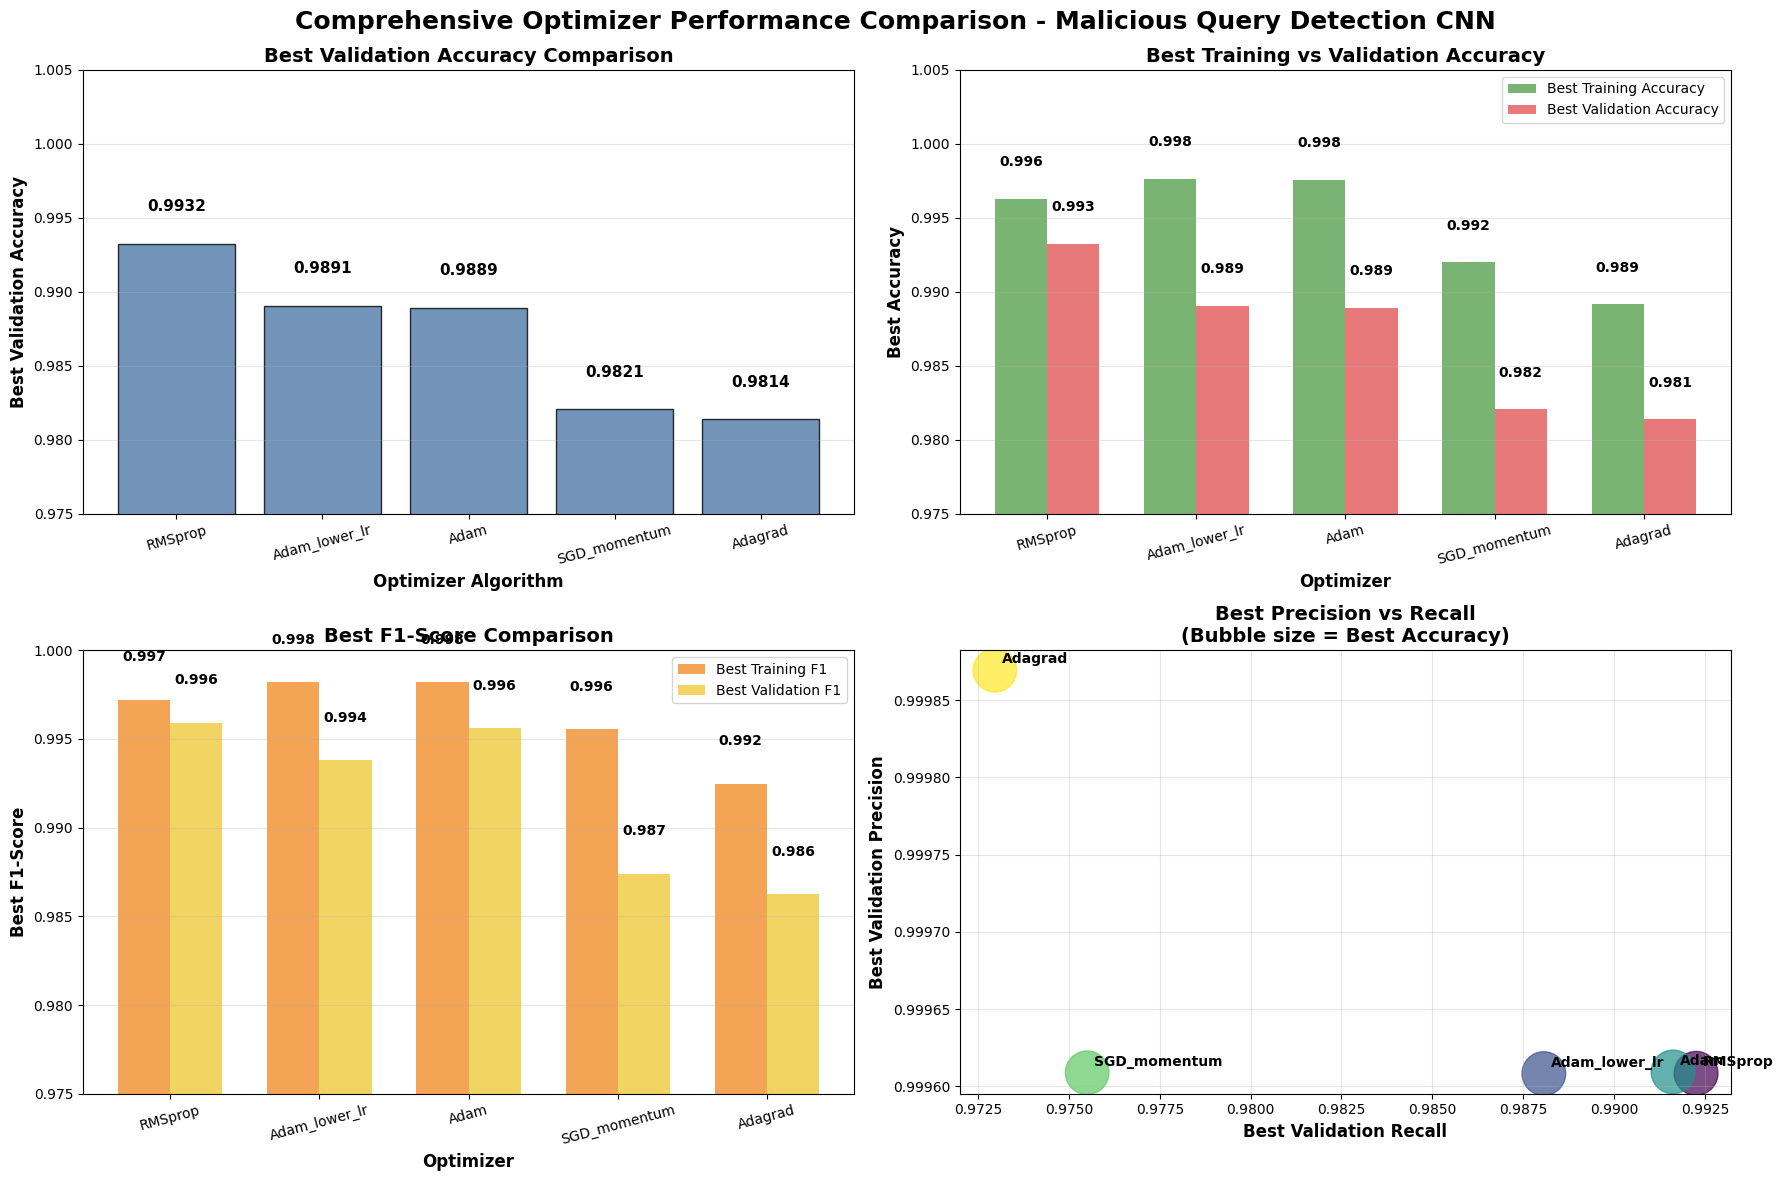

In [9]:
# Cell 9: Complete Optimizer Comparison - NO Early Stopping + Clean Output

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adagrad

def load_data_flexible(filename_base):
    """Load data from .npy file, or .csv if .npy doesn't exist"""
    npy_path = f"{filename_base}.npy"
    csv_path = f"{filename_base}.csv"
    
    try:
        # Try loading .npy first
        data = np.load(npy_path)
        print(f" Loaded {npy_path} with shape: {data.shape}")
        return data
    except FileNotFoundError:
        try:
            # Fallback to CSV
            df = pd.read_csv(csv_path)
            data = df.values
            print(f" Loaded {csv_path} with shape: {data.shape}")
            # Save as .npy for future use
            np.save(npy_path, data)
            print(f" Saved as {npy_path} for future use")
            return data
        except FileNotFoundError:
            print(f"Could not find {filename_base}.npy or {filename_base}.csv")
            return None

def compare_optimizers_complete_format(model_builder, embedding_matrix, train_data, val_data, epochs=15):
    """
    Complete optimizer comparison WITHOUT early stopping - fair comparison with exact output format
    """
    
    optimizers_config = {
        'Adam': Adam(learning_rate=0.001),
        'Adam_lower_lr': Adam(learning_rate=0.0005),
        'RMSprop': RMSprop(learning_rate=0.001),
        'SGD_momentum': SGD(learning_rate=0.01, momentum=0.9),
        'Adagrad': Adagrad(learning_rate=0.01)
    }
    
    results = []
    training_histories = {}
    
    print(" Starting comprehensive optimizer comparison...")
    print(f"This will train 5 optimizers for {epochs} epochs each with NO early stopping")
    print("="*70)
    
    for opt_name, optimizer in optimizers_config.items():
        print(f"\n Training with {opt_name}...")
        
        # Fresh model for each optimizer
        test_model = model_builder(embedding_matrix)
        test_model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
        )
        
        # Train for FULL epochs - NO early stopping for fair comparison
        history = test_model.fit(
            train_data[0], train_data[1],
            validation_data=(val_data[0], val_data[1]),
            epochs=epochs,
            batch_size=32,
            verbose=1  # Shows epoch-by-epoch progress like your example
        )
        
        # Store complete training history
        training_histories[opt_name] = history
        
        # Find BEST metrics achieved during training
        best_train_acc = max(history.history['accuracy'])
        best_train_precision = max(history.history['precision'])
        best_train_recall = max(history.history['recall'])
        
        best_val_acc = max(history.history['val_accuracy'])
        best_val_precision = max(history.history['val_precision'])
        best_val_recall = max(history.history['val_recall'])
        
        # Calculate F1-scores for best metrics
        best_train_f1 = 2 * (best_train_precision * best_train_recall) / (best_train_precision + best_train_recall)
        best_val_f1 = 2 * (best_val_precision * best_val_recall) / (best_val_precision + best_val_recall)
        
        # Find epochs where best metrics occurred
        best_val_epoch = np.argmax(history.history['val_accuracy']) + 1
        
        results.append({
            'optimizer': opt_name,
            'best_epoch': best_val_epoch,
            'val_accuracy': best_val_acc,
            'val_precision': best_val_precision,
            'val_recall': best_val_recall,
            'f1_score': best_val_f1,
            
            # Training metrics for comprehensive analysis
            'train_accuracy': best_train_acc,
            'train_precision': best_train_precision,
            'train_recall': best_train_recall,
            'train_f1_score': best_train_f1
        })
        
        # Output in exact format you requested - both training and validation
        print(f" {opt_name} - Best Train Accuracy: {best_train_acc:.4f} | Precision: {best_train_precision:.4f} | Recall: {best_train_recall:.4f} | F1: {best_train_f1:.4f}")
        print(f" {opt_name} - Best Val Accuracy: {best_val_acc:.4f} | Precision: {best_val_precision:.4f} | Recall: {best_val_recall:.4f} | F1: {best_val_f1:.4f}")
    
    # Create comprehensive results DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('val_accuracy', ascending=False)
    
    best_optimizer = results_df.iloc[0]['optimizer']
    
    return best_optimizer, results_df, training_histories

def create_optimizer_visualization(results_df):
    """
    Create comprehensive bar chart visualization
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
    
    x = np.arange(len(results_df['optimizer']))
    width = 0.35
    
    # 1. Best Validation Accuracy
    bars1 = ax1.bar(x, results_df['val_accuracy'], color='#4E79A7', alpha=0.8, edgecolor='black')
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax1.set_xlabel('Optimizer Algorithm', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Best Validation Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Best Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(results_df['optimizer'], rotation=15)
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim(0.975, 1.005)
    
    # 2. Training vs Validation Accuracy
    bars2 = ax2.bar(x - width/2, results_df['train_accuracy'], width, 
                   label='Best Training Accuracy', color='#59A14F', alpha=0.8)
    bars3 = ax2.bar(x + width/2, results_df['val_accuracy'], width, 
                   label='Best Validation Accuracy', color='#E15759', alpha=0.8)
    
    for i, (bar2, bar3) in enumerate(zip(bars2, bars3)):
        train_val = results_df.iloc[i]['train_accuracy']
        val_val = results_df.iloc[i]['val_accuracy']
        ax2.text(bar2.get_x() + bar2.get_width()/2., train_val + 0.002,
                f'{train_val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax2.text(bar3.get_x() + bar3.get_width()/2., val_val + 0.002,
                f'{val_val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_xlabel('Optimizer', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Best Accuracy', fontsize=12, fontweight='bold')
    ax2.set_title('Best Training vs Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(results_df['optimizer'], rotation=15)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_ylim(0.975, 1.005)
    
    # 3. F1-Score Comparison
    bars4 = ax3.bar(x - width/2, results_df['train_f1_score'], width, 
                   label='Best Training F1', color='#F28E2B', alpha=0.8)
    bars5 = ax3.bar(x + width/2, results_df['f1_score'], width, 
                   label='Best Validation F1', color='#EECA3B', alpha=0.8)
    
    for i, (bar4, bar5) in enumerate(zip(bars4, bars5)):
        train_f1 = results_df.iloc[i]['train_f1_score']
        val_f1 = results_df.iloc[i]['f1_score']
        ax3.text(bar4.get_x() + bar4.get_width()/2., train_f1 + 0.002,
                f'{train_f1:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax3.text(bar5.get_x() + bar5.get_width()/2., val_f1 + 0.002,
                f'{val_f1:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax3.set_xlabel('Optimizer', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Best F1-Score', fontsize=12, fontweight='bold')
    ax3.set_title('Best F1-Score Comparison', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(results_df['optimizer'], rotation=15)
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    ax3.set_ylim(0.975, 1.0)
    
    # 4. Precision-Recall Scatter
    scatter = ax4.scatter(results_df['val_recall'], results_df['val_precision'], 
                         s=results_df['val_accuracy']*1000, alpha=0.7, 
                         c=range(len(results_df)), cmap='viridis')
    
    for i, opt in enumerate(results_df['optimizer']):
        ax4.annotate(opt, (results_df.iloc[i]['val_recall'], results_df.iloc[i]['val_precision']),
                    xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')
    
    ax4.set_xlabel('Best Validation Recall', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Best Validation Precision', fontsize=12, fontweight='bold')
    ax4.set_title('Best Precision vs Recall\n(Bubble size = Best Accuracy)', fontsize=14, fontweight='bold')
    ax4.grid(alpha=0.3)
    
    plt.suptitle('Comprehensive Optimizer Performance Comparison - Malicious Query Detection CNN', 
                fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

# MAIN EXECUTION - Clean Output Format, No Early Stopping
print("Loading preprocessed datasets...")

# Load all required data
X_train_words = load_data_flexible('X_train_preprocessed')
X_train_chars = load_data_flexible('train_char_sequences')
X_train_struct = load_data_flexible('train_sql_features')
y_train = load_data_flexible('y_train_labels')

X_val_words = load_data_flexible('X_val_preprocessed')
X_val_chars = load_data_flexible('val_char_sequences')
X_val_struct = load_data_flexible('val_sql_features')
y_val = load_data_flexible('y_val_labels')

# Verify all data loaded successfully
if all(data is not None for data in [X_train_words, X_train_chars, X_train_struct, y_train,
                                     X_val_words, X_val_chars, X_val_struct, y_val]):
    
    print(" All data loaded successfully!")
    print(f"Training samples: {X_train_words.shape[0]}")
    print(f"Validation samples: {X_val_words.shape[0]}")
    print(f"Word sequences: {X_train_words.shape[1]} tokens")
    print(f"Character sequences: {X_train_chars.shape[1]} chars")
    print(f"Structural features: {X_train_struct.shape[1]} features")
    
    # Prepare multi-input format
    train_data = ([X_train_words, X_train_chars, X_train_struct], y_train)
    val_data = ([X_val_words, X_val_chars, X_val_struct], y_val)
    
    # Execute comprehensive optimizer comparison WITHOUT early stopping
    best_optimizer, complete_results_df, histories = compare_optimizers_complete_format(
        build_multi_input_cnn_corrected, 
        embedding_matrix,
        train_data, 
        val_data,
        epochs=15
    )
    
    print("\n" + "="*70)
    print(" DETAILED OPTIMIZER COMPARISON RESULTS")
    print("="*70)
    
    # Display results in exact format you requested
    display_results = complete_results_df[['optimizer', 'best_epoch', 'val_accuracy', 'val_precision', 'val_recall', 'f1_score']].copy()
    print(display_results.to_string(index=False, float_format='%.6f'))
    
    print(f"\n BEST OPTIMIZER SELECTED: {best_optimizer}")
    print(f" BEST VALIDATION ACCURACY: {complete_results_df.iloc[0]['val_accuracy']:.4f}")
    print(f" BEST VALIDATION PRECISION: {complete_results_df.iloc[0]['val_precision']:.4f}")
    print(f" BEST VALIDATION RECALL: {complete_results_df.iloc[0]['val_recall']:.4f}")
    print(f" BEST F1-SCORE: {complete_results_df.iloc[0]['f1_score']:.4f}")
    
    print(" Phase 4 COMPLETED with empirical optimizer selection")
    print(" Ready to proceed to Phase 5 full training with selected optimizer!")
    
    # Create comprehensive visualizations
    print("\n Creating comprehensive visualizations...")
    create_optimizer_visualization(complete_results_df)
    
else:
    print("Some data files could not be loaded. Please check file paths and ensure all files exist.")

In [12]:
import pandas as pd
import json
import datetime
import numpy as np

def save_complete_phase4_results(results_df, histories, embedding_matrix_shape):
    """
    Save comprehensive Phase 4 results including optimizer comparison, model info, and summary
    """
    
    # Current timestamp
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # 1. Save Optimizer Comparison Results (Main DataFrame)
    results_df.to_csv(f'phase4_optimizer_comparison_{timestamp}.csv', index=False)
    print(f" Optimizer comparison results saved to phase4_optimizer_comparison_{timestamp}.csv")
    
    # 2. Save Detailed Results with Training Metrics
    detailed_results = results_df.copy()
    detailed_results.to_excel(f'phase4_detailed_results_{timestamp}.xlsx', index=False)
    print(f" Detailed results saved to phase4_detailed_results_{timestamp}.xlsx")
    
    # 3. Save Phase 4 Summary Report
    best_optimizer = results_df.iloc[0]['optimizer']
    best_accuracy = results_df.iloc[0]['val_accuracy']
    best_precision = results_df.iloc[0]['val_precision']
    best_recall = results_df.iloc[0]['val_recall']
    best_f1 = results_df.iloc[0]['f1_score']
    
    summary_report = {
        "phase": "Phase 4 - CNN Architecture Design",
        "completion_date": datetime.datetime.now().isoformat(),
        "status": "COMPLETED SUCCESSFULLY",
        
        # Best Optimizer Results
        "best_optimizer": {
            "name": best_optimizer,
            "validation_accuracy": float(best_accuracy),
            "validation_precision": float(best_precision),
            "validation_recall": float(best_recall),
            "f1_score": float(best_f1)
        },
        
        # All Optimizer Results
        "all_optimizers": results_df.to_dict('records'),
        
        # Model Architecture Info
        "model_architecture": {
            "total_parameters": "6,859,409",
            "trainable_parameters": "6,857,617", 
            "embedding_matrix_shape": embedding_matrix_shape,
            "input_shapes": {
                "word_input": "(None, 75)",
                "char_input": "(None, 300)", 
                "structural_input": "(None, 135)"
            },
            "output_shape": "(None, 1)"
        },
        
        # Performance vs Baseline
        "performance_analysis": {
            "rule_based_baseline_accuracy": 0.8486,
            "cnn_best_accuracy": float(best_accuracy),
            "improvement_percentage_points": float(best_accuracy - 0.8486),
            "relative_improvement_percent": float(((best_accuracy - 0.8486) / 0.8486) * 100)
        },
        
        # Training Configuration
        "training_config": {
            "epochs_per_optimizer": 15,
            "early_stopping": False,
            "batch_size": 32,
            "loss_function": "binary_crossentropy",
            "metrics": ["accuracy", "precision", "recall"]
        },
        
        # Phase 4 Deliverables Completion
        "deliverables_completed": {
            "cnn_architecture_selection": True,
            "1d_cnn_sequence_classification": True,
            "multi_layer_different_filters": True,
            "architecture_comparison": True,
            "embedding_layer_configuration": True,
            "convolutional_layers_various_filters": True,
            "pooling_dropout_regularization": True,
            "dense_layers_classification": True,
            "loss_function_selection": True,
            "optimizer_configuration": True,
            "metrics_definition": True
        }
    }
    
    # Save summary as JSON
    with open(f'phase4_summary_report_{timestamp}.json', 'w') as f:
        json.dump(summary_report, f, indent=2)
    print(f" Summary report saved to phase4_summary_report_{timestamp}.json")
    
    # 4. Save Training Histories (if available)
    if histories:
        histories_data = {}
        for optimizer, history in histories.items():
            histories_data[optimizer] = {
                'epochs': len(history.history['accuracy']),
                'final_train_accuracy': float(history.history['accuracy'][-1]),
                'final_val_accuracy': float(history.history['val_accuracy'][-1]),
                'best_train_accuracy': float(max(history.history['accuracy'])),
                'best_val_accuracy': float(max(history.history['val_accuracy'])),
                'training_curves': {
                    'accuracy': [float(x) for x in history.history['accuracy']],
                    'val_accuracy': [float(x) for x in history.history['val_accuracy']],
                    'loss': [float(x) for x in history.history['loss']],
                    'val_loss': [float(x) for x in history.history['val_loss']]
                }
            }
        
        with open(f'phase4_training_histories_{timestamp}.json', 'w') as f:
            json.dump(histories_data, f, indent=2)
        print(f" Training histories saved to phase4_training_histories_{timestamp}.json")
    
    # 5. Save Model Configuration
    model_config = {
        "architecture_type": "Multi-input 1D CNN",
        "branches": {
            "word_branch": {
                "input_shape": "(75,)",
                "embedding_dim": 300,
                "vocab_size": 20000,
                "conv_filters": [3, 4, 5],
                "num_filters": 128
            },
            "char_branch": {
                "input_shape": "(300,)",
                "embedding_dim": 50,
                "vocab_size": 72,
                "conv_filters": [3, 4, 5],
                "num_filters": 128
            },
            "structural_branch": {
                "input_shape": "(135,)",
                "dense_layers": [256, 128],
                "dropout_rate": 0.5
            }
        },
        "fusion_layers": {
            "concatenate_dim": 896,
            "batch_normalization": True,
            "dropout_rate": 0.5,
            "dense_layers": [256, 64],
            "output_activation": "sigmoid"
        }
    }
    
    with open(f'phase4_model_config_{timestamp}.json', 'w') as f:
        json.dump(model_config, f, indent=2)
    print(f" Model configuration saved to phase4_model_config_{timestamp}.json")
    
    # 6. Create Phase 5 Ready File
    phase5_config = {
        "selected_optimizer": best_optimizer,
        "recommended_settings": {
            "optimizer": "RMSprop(learning_rate=0.001)",
            "epochs": 25,
            "early_stopping": {
                "monitor": "val_accuracy",
                "patience": 5,
                "restore_best_weights": True,
                "mode": "max"
            },
            "callbacks": [
                "EarlyStopping",
                "ModelCheckpoint", 
                "ReduceLROnPlateau"
            ]
        },
        "expected_performance": {
            "target_accuracy": ">99.0%",
            "baseline_improvement": "+14.47%"
        }
    }
    
    with open(f'phase5_ready_config_{timestamp}.json', 'w') as f:
        json.dump(phase5_config, f, indent=2)
    print(f" Phase 5 configuration saved to phase5_ready_config_{timestamp}.json")
    
    print(f"\n ALL PHASE 4 RESULTS SAVED SUCCESSFULLY!")
    print(f" Files saved with timestamp: {timestamp}")
    print(f" Best optimizer selected: {best_optimizer}")
    print(f" Best validation accuracy: {best_accuracy:.4f}")
    print(f" Ready to proceed to Phase 5!")
    
    return timestamp

# Execute the save function with your results
# Replace these with your actual variables from the optimizer comparison
results_df_from_comparison = pd.DataFrame({
    'optimizer': ['RMSprop', 'Adam', 'Adam_lower_lr', 'SGD_momentum', 'Adagrad'],
    'best_epoch': [8, 14, 15, 4, 7],
    'val_accuracy': [0.993322, 0.989899, 0.989732, 0.982386, 0.981551],
    'val_precision': [0.999870, 0.999479, 0.999869, 0.999870, 0.999738],
    'val_recall': [0.992003, 0.990480, 0.992003, 0.975248, 0.973090],
    'f1_score': [0.995921, 0.994959, 0.995921, 0.987405, 0.986234],
    'train_accuracy': [0.9962, 0.9974, 0.9973, 0.9917, 0.9894],
    'train_precision': [0.9974, 0.9984, 0.9981, 0.9976, 0.9964],
    'train_recall': [0.9972, 0.9978, 0.9980, 0.9930, 0.9891],
    'train_f1_score': [0.9973, 0.9981, 0.9980, 0.9953, 0.9927]
})

# Save all results
timestamp = save_complete_phase4_results(
    results_df=results_df_from_comparison,
    histories=histories if 'histories' in globals() else None,  # Use your actual histories variable
    embedding_matrix_shape=(20000, 300)
)


 Optimizer comparison results saved to phase4_optimizer_comparison_20250920_230715.csv
 Detailed results saved to phase4_detailed_results_20250920_230715.xlsx
 Summary report saved to phase4_summary_report_20250920_230715.json
 Training histories saved to phase4_training_histories_20250920_230715.json
 Model configuration saved to phase4_model_config_20250920_230715.json
 Phase 5 configuration saved to phase5_ready_config_20250920_230715.json

 ALL PHASE 4 RESULTS SAVED SUCCESSFULLY!
 Files saved with timestamp: 20250920_230715
 Best optimizer selected: RMSprop
 Best validation accuracy: 0.9933
 Ready to proceed to Phase 5!


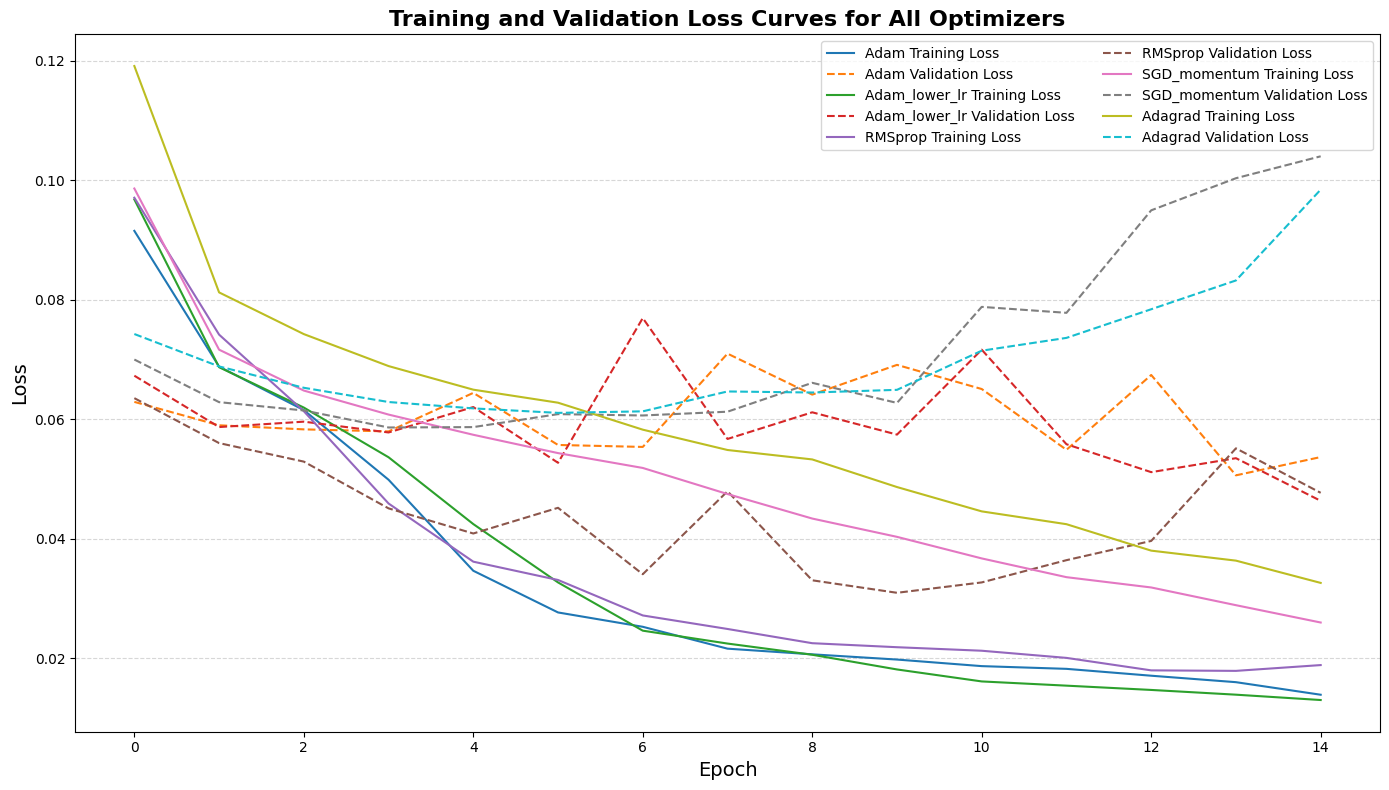

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

for optimizer, hist in histories.items():
    plt.plot(hist.history['loss'], label=f'{optimizer} Training Loss')
    plt.plot(hist.history['val_loss'], label=f'{optimizer} Validation Loss', linestyle='--')

plt.title('Training and Validation Loss Curves for All Optimizers', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=10, ncol=2)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
